# Exercise 4: Hate Speech Classification using Multinomial Naive Bayes

Instructions:
- You do not need to split your data. Use the training, validation and test sets provided below.
- Use Multinomial Naive Bayes to train a model that can classify if a sentence is a hate speech or non-hate speech
- A sentence with a label of zero (0) is classified as non-hate speech
- A sentence with a label of one (1) is classified as a hate speech

Apply text pre-processing techniques such as
- Converting to lowercase
- Stop word Removal
- Removal of digits, special characters
- Stemming or Lemmatization but not both
- Count Vectorizer or TF-IDF Vectorizer but not both

Evaluate your model by:
- Providing input by yourself
- Creating a Confusion Matrix
- Calculating the Accuracy, Precision, Recall and F1-Score

In [ ]:
import pandas as pd
#

In [2]:
splits = {'train': 'unique_train_dataset.csv', 'validation': 'unique_validation_dataset.csv', 'test': 'unique_test_dataset.csv'}

**Training Set**

Use this to train your model

In [5]:
df_train = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["train"])
df_train.head()

,text,label
0,Presidential candidate Mar Roxas implies that ...,1
1,Parang may mali na sumunod ang patalastas ng N...,1
2,Bet ko. Pula Ang Kulay Ng Posas,1
3,[USERNAME] kakampink,0
4,Bakit parang tahimik ang mga PINK about Doc Wi...,1


**Validation Set**

Use this set to evaluate your model

In [6]:
df_validation = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["validation"])

**Test Set**
  
Use this set to test your model

In [7]:
df_test = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["test"])

## A. Understanding your training data

1. Check the first 10 rows of the training dataset

In [8]:
# put your answer here
df_train.head(10)

,text,label
0,Presidential candidate Mar Roxas implies that ...,1
1,Parang may mali na sumunod ang patalastas ng N...,1
2,Bet ko. Pula Ang Kulay Ng Posas,1
3,[USERNAME] kakampink,0
4,Bakit parang tahimik ang mga PINK about Doc Wi...,1
5,"""Ang sinungaling sa umpisa ay sinungaling hang...",1
6,Leni Kiko,0
7,Nahiya si Binay sa Makati kaya dito na lang sa...,1
8,Another reminderHalalan,0
9,[USERNAME] Maybe because VP Leni Sen Kiko and ...,0


2. Check how many rows and columns are in the training dataset using `.info()`

In [9]:
# put your answer here
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21773 entries, 0 to 21772
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    21773 non-null  object
 1   label   21773 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 340.3+ KB


3. Check for NaN values

In [10]:
# put your answer here
df_train.isna().sum()

,0
text,0
label,0


4. Check for duplicate rows

In [11]:
# put your answer here
pd.DataFrame(df_train)
duplicate_rows = df_train.duplicated()

print('duplicated rows: ', duplicate_rows)

duplicated rows:  0        False
1        False
2        False
3        False
4        False
         ...  
21768    False
21769    False
21770    False
21771    False
21772    False
Length: 21773, dtype: bool


5. Check how many rows belong to each class

In [12]:
# put your answer here
df_train['label'].value_counts()

,count
label,
1,10994
0,10779


In [25]:
df_train['text'].value_counts()

,count
text,
let leni lead,12
marco magnanakaw,10
leni kiko,10
leni presid,8
usernam let leni lead,8
...,...
dutert lead morn roxa suddenli rank st lose shit realli,1
shut fuck blengblong stupid leak,1
usernam usernameandusernam kung gusto mo tlaga ng pagbabagokung ayaw mo kay bbm much better na si norberto gonzal si ping ang iboto moma qualifi sila kesa sahindi mo malaman kung anong pagkatao meron,1


## B. Text pre-processing

6. Remove duplicate rows

In [26]:
# put your answer here
df_train.drop_duplicates(inplace=True)

7. Remove rows with NaN values

In [27]:
# put your answer here
df_train.dropna(inplace=True)

8. Convert all text to lowercase

In [28]:
# put your answer here
df_train["text"] = df_train["text"].str.lower()

9. Remove digits, URLS and special characters

In [29]:
# put your answer here
import re
df_train['text'] = df_train['text'].apply(lambda x: re.sub(r'http\S+', '', x))
df_train['text'] = df_train['text'].apply(lambda x: re.sub(r'\d+', '', x))
df_train['text'] = df_train['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

10. Remove stop words

In [31]:
# put your answer here
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df_train['text'] = df_train['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


11. Use Stemming or Lemmatization

In [32]:
# put your answer here
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
df_train["text"] = df_train["text"].apply(lambda x: " ".join([stemmer.stem(word) for word in x.split()]))

## C. Training your model

12. Put all text training data in variable **X_train**

In [33]:
# put your answer here
x_train = df_train["text"]


13. Put all training data labels in variable **y_train**

In [34]:
# put your answer here
y_train = df_train["label"]

14. Use `CountVectorizer()` or `TfidfVectorizer()` to convert text data to its numerical form.

Put the converted data to **X_train_transformed** variable

In [35]:
# put your answer here
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_transformed = vectorizer.fit_transform(x_train)

15. Create an instance of `MultinomalNB()`

In [36]:
# put your answer here
from sklearn.naive_bayes import MultinomialNB
multi_nb = MultinomialNB()

16. Train the model using `.fit()`

In [37]:
# put your answer here
multi_nb.fit(X_train_transformed, y_train)

MultinomialNB()

## D. Evaluate your model

17. Use `.predict()` to generate model predictions using the **validation dataset**


- Put all text validation data in **X_validation** variable

- Convert **X_validation** to its numerical form.

- Put the converted data to **X_validation_transformed**

- Put all predictions in **y_validation_pred** variable

In [38]:
# put your answer here
X_validation = df_validation["text"]
X_validation_transformed = vectorizer.transform(X_validation)
y_validation_pred = multi_nb.predict(X_validation_transformed)

18. Get the Accuracy, Precision, Recall and F1-Score of the model using the **validation dataset**

- Put all validation data labels in **y_validation** variable

In [39]:
# put your answer here
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_validation = df_validation["label"]
accuracy = accuracy_score(y_validation, y_validation_pred)
precision = precision_score(y_validation, y_validation_pred)
recall = recall_score(y_validation, y_validation_pred)
f1 = f1_score(y_validation, y_validation_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.8089285714285714
Precision: 0.7679658952496955
Recall: 0.8911660777385159
F1-Score: 0.8249918220477592


19. Create a confusion matrix using the **validation dataset**

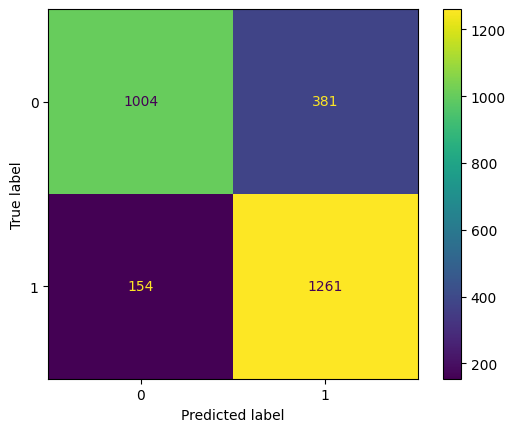

In [40]:
# put your answer here
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
matrix = confusion_matrix(y_validation, y_validation_pred)

display = ConfusionMatrixDisplay(confusion_matrix=matrix)
display.plot()
plt.show()

20. Use `.predict()` to generate the model predictions using the **test dataset**


- Put all text validation data in **X_test** variable

- Convert **X_test** to its numerical form.

- Put the converted data to **X_test_transformed**

- Put all predictions in **y_test_pred** variable

In [42]:
# put your answer here
X_test = df_test["text"]
X_test_transformed = vectorizer.transform(X_test)
y_test_pred = multi_nb.predict(X_test_transformed)

21. Get the Accuracy, Precision, Recall and F1-Score of the model using the **test dataset**

- Put all test data labels in **y_validation** variable



In [45]:
# put your answer here
y_test = df_test["label"]
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.8135231316725978
Precision: 0.7680981595092025
Recall: 0.8955650929899857
F1-Score: 0.8269484808454426


22. Create a confusion matrix using the **test dataset**

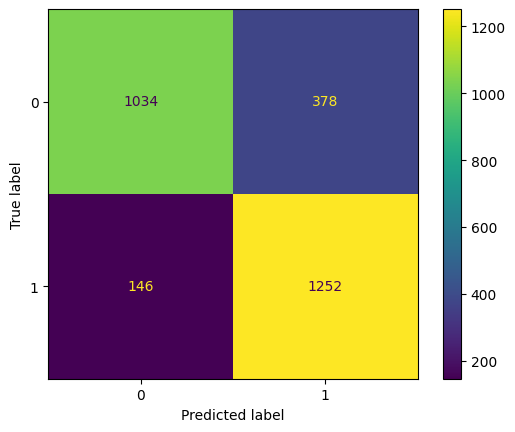

In [46]:
# put your answer here
matrix = confusion_matrix(y_test, y_test_pred)

test_matrix = ConfusionMatrixDisplay(confusion_matrix=matrix)
test_matrix.plot()
plt.show()

## E. Test the model

23. Test the model by providing a non-hate speech input. The model should predict it as 0

In [47]:
# put your answer here
input_text = "I'm so happy today!"
input_text_transformed = vectorizer.transform([input_text])
prediction = multi_nb.predict(input_text_transformed)
print(prediction)

[0]


24. Test the model by providing a hate speech input. The model should predict it as 1

In [48]:
# put your answer here
input_text = "I hate you"
input_text_transformed = vectorizer.transform([input_text])
prediction = multi_nb.predict(input_text_transformed)
print(prediction)

[1]
